# HW 3: Unsupervised Learning Practice

# Junyang You

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA

# Import the red wine csv file

In [2]:
df=pd.read_csv("winequality-red.csv", sep=';')
df.head(100)

FileNotFoundError: [Errno 2] No such file or directory: 'winequality-red.csv'

# 1. Use K Means Cluster Analysis to identify cluster(s) of observations that have high and low values of the wine quality. (Assume all variables are continuous.)

# Describe variables that cluster with higher values of wine quality. Describe variables that cluster with lower values of wine quality.

# If you want to make a good bottle of wine, then what characteristics are most important according to this analysis?

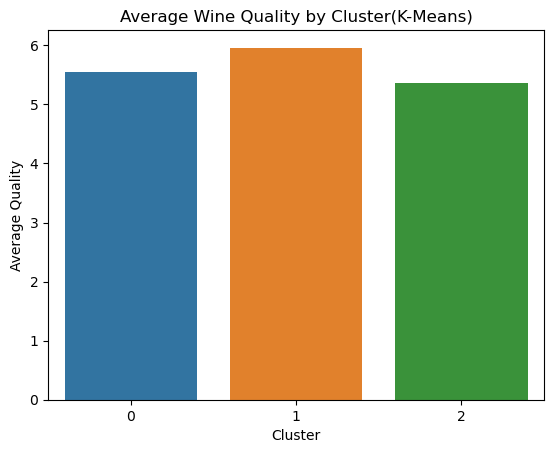

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
cluster,,,,,,,,,,,,
1,10.067131,0.405080,0.469761,2.582570,0.100460,10.888446,30.627490,0.997574,3.195040,0.752131,10.724037,5.960159
0,7.189889,0.609342,0.123047,2.214058,0.078553,13.507618,34.894737,0.995896,3.405762,0.609224,10.494044,5.552632
2,8.155467,0.535173,0.289680,3.105467,0.087235,27.108000,89.954667,0.997276,3.284267,0.626533,9.883156,5.362667


In [24]:
X=df.drop("quality", axis=1)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"]=kmeans.fit_predict(X_scaled)
cluster_means=df.groupby("cluster").mean()

sns.barplot(x=cluster_means.index, y=cluster_means["quality"])
plt.title("Average Wine Quality by Cluster(K-Means)")
plt.xlabel("Cluster")
plt.ylabel("Average Quality")
plt.show()

cluster_means.sort_values("quality", ascending=False)

### From K-Means, Cluster 0 has the highest average quality. Wines in this group have higher alcohol, citric acid, and sulphates, and lower volatile acidity and chlorides. The lowest quality cluster shows that more acidity and less alcohol.
### So if I want to make a good bottle of wine, the key is higher alcohol and sulphates and lower volatile acidity. These traits clearly cluster with better wine quality

# 2. Use Hierarchical Cluster Analysis to identify cluster(s) of observations that have high and low values of the wine quality. (Assume all variables are continuous.) Use complete linkage and the same number of groups that you found to be the most meaningful in question 1.

# Describe variables that cluster with higher values of wine quality. Describe variables that cluster with lower values of wine quality.

# If you want to make a good bottle of wine, then what characteristics are most important according to this analysis? Have your conclusions changed using Hierarchical clustering rather than k means clustering? Present any figures that assist you in your analysis.

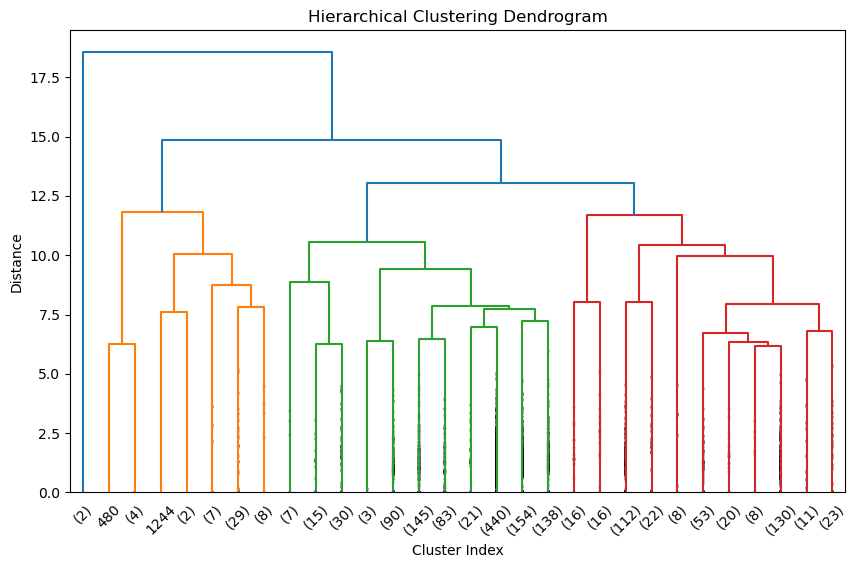

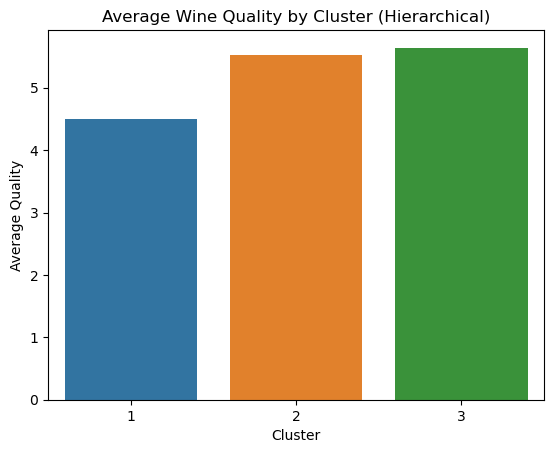

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
h_cluster,,,,,,,,,,,,,
3,8.332880,0.528796,0.267463,2.349612,0.086580,15.387702,44.939806,0.996694,3.312790,0.657159,10.429676,5.641424,0.749515
2,7.921154,0.501250,0.351923,8.157692,0.093692,30.192308,91.461538,0.998243,3.277115,0.650192,10.263462,5.519231,1.769231
1,8.450000,0.465000,0.880000,2.600000,0.610500,20.000000,57.000000,0.998200,2.900000,1.630000,9.400000,4.500000,1.000000


In [28]:
linkage_matrix=linkage(X_scaled, method='complete')

plt.figure(figsize=(10,6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=45,
           leaf_font_size=10, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Index")
plt.ylabel("Distance")
plt.show()

df["h_cluster"]=fcluster(linkage_matrix, 3, criterion='maxclust')
h_cluster_means=df.groupby("h_cluster").mean()

sns.barplot(x=h_cluster_means.index, y=h_cluster_means["quality"])
plt.title("Average Wine Quality by Cluster (Hierarchical)")
plt.xlabel("Cluster")
plt.ylabel("Average Quality")
plt.show()

h_cluster_means.sort_values("quality", ascending=False)

### The hierarchical clusters show a similar trend. The best quality wines still have higher alcohol and balanced acidity while lower quality ones have low alcohol and higher volatile acidity. The difference is that this method also shows how clusters merge. It shows that wines with similar levels of alcohol and sulfates tend to be grouped together. My conclusion remains the same.

# 3. Use Principal Components Analysis to reduce the dimensions of your data. How much of the variation in your data is explained by the first two principal components. How might you use the first two components to do supervised learning on some other variable tied to wine (e.g. - wine price)?

Variance explained by each principal component:
PC1: 0.282
PC2: 0.175
PC3: 0.141
PC4: 0.110
PC5: 0.087
PC6: 0.060
PC7: 0.053
PC8: 0.038
PC9: 0.031
PC10: 0.016
PC11: 0.005

Total variance explained by the first two PCs: 0.457


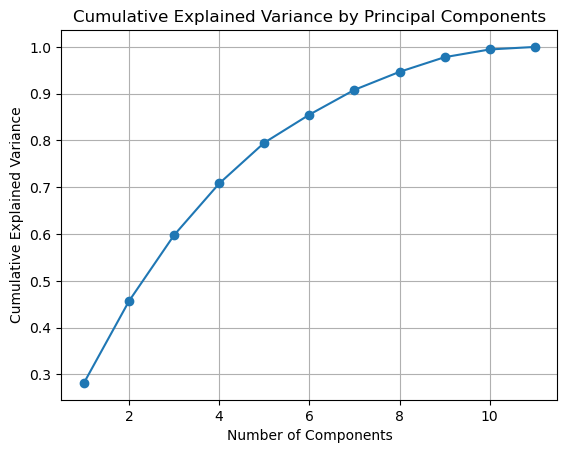

In [29]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)
explained_variance=pca.explained_variance_ratio_
print("Variance explained by each principal component:")
for i, var in enumerate(explained_variance, 1):
    print(f"PC{i}: {var:.3f}")

total_var_2=explained_variance[0]+explained_variance[1]
print(f"\nTotal variance explained by the first two PCs: {total_var_2:.3f}")

plt.plot(range(1, len(explained_variance)+1), np.cumsum(explained_variance), marker='o')
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

### The first two principal components explain about 45.7% of the total variation. So basically, almost half of the differences between wines can be captured by just these two components. PC1 is mostly about alcohol and acidity, and PC2 is more about sulphates and density. These two already give a clear view of the data and could work well if I wanted to predict something like wine price or rating. 